# Priprema podataka za klasifikaciju proizvoda
Ova sveska učitava, analizira, čisti i priprema skup proizvoda za model automatske klasifikacije kategorija. Obrada koristi relativne putanje i sprečava curenje podataka između trening i test skupa.

In [10]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
DATA_PATH = Path("IMLP6_TASK_03-products.csv")
OUTPUT_DIR = Path("data/processed")

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 2)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV fajl nije pronađen: {DATA_PATH.resolve()}")

data_raw = pd.read_csv(DATA_PATH)
raw_shape = data_raw.shape
print(f"Učitano je {raw_shape[0]:,} redova i {raw_shape[1]} kolona.")

Učitano je 35,311 redova i 8 kolona.


## 1. Početna analiza kvaliteta
Proveravamo nazive i tipove kolona, prazne vrednosti, kardinalnost, duplikate i raspodelu ciljne kategorije pre bilo kakve izmene podataka.

Potpuno duplirani redovi: 0


,dtype,missing,missing_pct,unique
product_id,int64,0,0.00,35311
product_title,str,172,0.49,30861
merchant_id,int64,0,0.00,306
category_label,str,44,0.12,14
product_code,str,95,0.27,35217
number_of_views,float64,14,0.04,5000
merchant_rating,float64,170,0.48,42
listing_date,str,59,0.17,1097


,product_id,product_title,merchant_id,category_label,product_code,number_of_views,merchant_rating,listing_date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


,count
category,
Fridge Freezers,5495
Washing Machines,4036
Mobile Phones,4020
CPUs,3771
TVs,3564
Fridges,3457
Dishwashers,3418
Digital Cameras,2696
Microwaves,2338


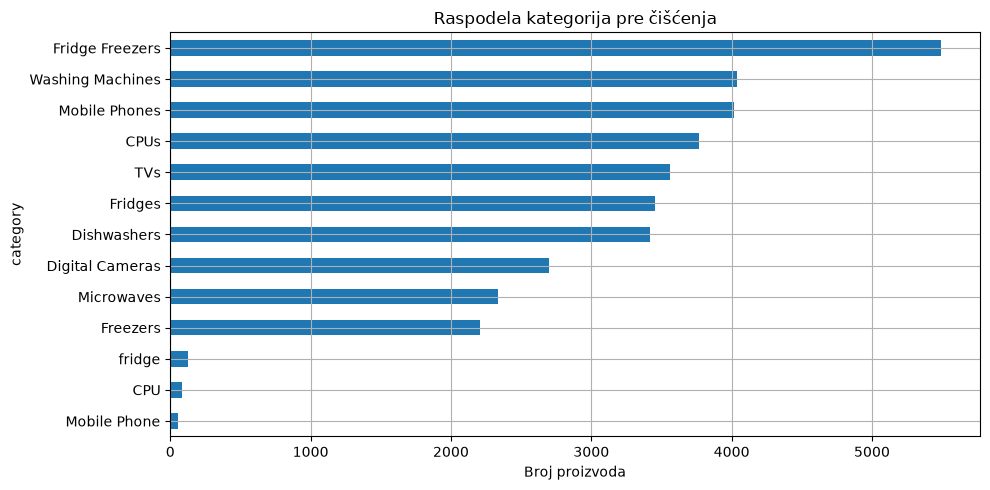

In [11]:
def normalize_column_name(column_name):
    normalized = re.sub(r"[^0-9a-zA-Z]+", "_", column_name.strip().lower())
    return normalized.strip("_")

data_raw.columns = [normalize_column_name(column) for column in data_raw.columns]

quality_report = pd.DataFrame(
    {
        "dtype": data_raw.dtypes.astype(str),
        "missing": data_raw.isna().sum(),
        "missing_pct": data_raw.isna().mean().mul(100).round(2),
        "unique": data_raw.nunique(dropna=False),
    }
)

print(f"Potpuno duplirani redovi: {data_raw.duplicated().sum():,}")
display(quality_report)
display(data_raw.head())

target_before_cleaning = (
    data_raw["category_label"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("category")
    .to_frame("count")
)
display(target_before_cleaning)

target_before_cleaning.drop(index=pd.NA, errors="ignore").sort_values("count").plot.barh(
    legend=False, title="Raspodela kategorija pre čišćenja"
 )
plt.xlabel("Broj proizvoda")
plt.tight_layout()
plt.show()

## 2. Čišćenje i standardizacija
Uklanjamo zapise bez naslova ili cilja, objedinjujemo neujednačene oznake kategorija, normalizujemo tekst i datume, rešavamo nedostajuće vrednosti i uklanjamo konfliktne ili ponovljene naslove. Identifikatori ostaju radi praćenja, ali se ne koriste kao karakteristike modela.

In [12]:
data = data_raw.copy()

text_columns = ["product_title", "category_label", "product_code"]
for column in text_columns:
    data[column] = (
        data[column]
        .astype("string")
        .str.normalize("NFKC")
        .str.strip()
        .replace("", pd.NA)
    )

required_missing_mask = data[["product_title", "category_label"]].isna().any(axis=1)
dropped_required = int(required_missing_mask.sum())
data = data.loc[~required_missing_mask].copy()

category_aliases = {
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
    "fridge": "Fridges",
}
data["category_label"] = data["category_label"].replace(category_aliases)

data["product_title_clean"] = (
    data["product_title"]
    .str.lower()
    .str.replace(r"[\W_]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
 )
data = data.loc[data["product_title_clean"].ne("")].copy()

data["number_of_views_missing"] = data["number_of_views"].isna().astype("int8")
data["merchant_rating_missing"] = data["merchant_rating"].isna().astype("int8")
data["number_of_views"] = pd.to_numeric(data["number_of_views"], errors="coerce").clip(lower=0)
data["merchant_rating"] = pd.to_numeric(data["merchant_rating"], errors="coerce")
data.loc[~data["merchant_rating"].between(1, 5), "merchant_rating"] = np.nan
data["number_of_views"] = data["number_of_views"].fillna(data["number_of_views"].median())
data["merchant_rating"] = data["merchant_rating"].fillna(data["merchant_rating"].median())

data["listing_date"] = pd.to_datetime(
    data["listing_date"], format="%m/%d/%Y", errors="coerce"
 )
data["listing_date_missing"] = data["listing_date"].isna().astype("int8")
median_listing_date = data["listing_date"].dropna().median()
data["listing_date"] = data["listing_date"].fillna(median_listing_date)
data["listing_year"] = data["listing_date"].dt.year
data["listing_month"] = data["listing_date"].dt.month
data["listing_dayofweek"] = data["listing_date"].dt.dayofweek
data["product_code"] = data["product_code"].fillna("unknown")

labels_per_title = data.groupby("product_title_clean")["category_label"].nunique()
ambiguous_titles = labels_per_title[labels_per_title.gt(1)].index
ambiguous_mask = data["product_title_clean"].isin(ambiguous_titles)
removed_ambiguous = int(ambiguous_mask.sum())
data = data.loc[~ambiguous_mask].copy()

data = data.sort_values("number_of_views", ascending=False)
removed_repeated_titles = int(data.duplicated("product_title_clean").sum())
data_clean = (
    data.drop_duplicates("product_title_clean", keep="first")
    .sort_values("product_id")
    .reset_index(drop=True)
 )

cleaning_summary = pd.Series(
    {
        "raw_rows": raw_shape[0],
        "dropped_missing_title_or_target": dropped_required,
        "removed_ambiguous_title_rows": removed_ambiguous,
        "removed_repeated_title_rows": removed_repeated_titles,
        "clean_rows": len(data_clean),
        "clean_categories": data_clean["category_label"].nunique(),
        "remaining_missing_values": int(data_clean.isna().sum().sum()),
    },
    name="value",
 )
display(cleaning_summary.to_frame())
display(data_clean["category_label"].value_counts().rename_axis("category").to_frame("count"))

,value
raw_rows,35311
dropped_missing_title_or_target,215
removed_ambiguous_title_rows,4
removed_repeated_title_rows,4276
clean_rows,30816
clean_categories,10
remaining_missing_values,0


,count
category,
Fridge Freezers,4806
Mobile Phones,3662
Washing Machines,3399
TVs,3275
Fridges,3188
CPUs,3043
Dishwashers,3041
Digital Cameras,2405
Microwaves,2094


## 3. Priprema za modeliranje
Skup delimo stratifikovano na trening i test podatke. Naslov se pretvara u TF-IDF karakteristike, numeričke kolone se imputiraju i standardizuju, a `merchant_id` se kodira bez korišćenja skoro jedinstvenih identifikatora `product_id` i `product_code`. Duplikati normalizovanih naslova uklonjeni su pre podele, pa isti proizvod ne može završiti u oba skupa.

In [13]:
feature_columns = [
    "product_title_clean",
    "merchant_id",
    "number_of_views",
    "merchant_rating",
    "listing_year",
    "listing_month",
    "listing_dayofweek",
    "number_of_views_missing",
    "merchant_rating_missing",
    "listing_date_missing",
]
target_column = "category_label"

model_data = data_clean[feature_columns + [target_column]].copy()
model_data["merchant_id"] = model_data["merchant_id"].astype("string")

X = model_data[feature_columns]
y = model_data[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
 )

numeric_columns = [
    "number_of_views",
    "merchant_rating",
    "listing_year",
    "listing_month",
    "listing_dayofweek",
    "number_of_views_missing",
    "merchant_rating_missing",
    "listing_date_missing",
]
categorical_columns = ["merchant_id"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
 )

preprocessor = ColumnTransformer(
    transformers=[
        (
            "title_tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                max_features=30_000,
                sublinear_tf=True,
                dtype=np.float32,
            ),
            "product_title_clean",
        ),
        ("numeric", numeric_pipeline, numeric_columns),
        (
            "merchant",
            OneHotEncoder(handle_unknown="ignore", dtype=np.float32),
            categorical_columns,
        ),
    ],
    remainder="drop",
 )

X_train_prepared = preprocessor.fit_transform(X_train, y_train)
X_test_prepared = preprocessor.transform(X_test)

assert data_clean["product_title_clean"].is_unique
assert data_clean.isna().sum().sum() == 0
assert y_train.nunique() == y_test.nunique() == data_clean[target_column].nunique()
assert set(X_train["product_title_clean"]).isdisjoint(X_test["product_title_clean"])
assert X_train_prepared.shape[0] == len(X_train)
assert X_test_prepared.shape[0] == len(X_test)
assert X_train_prepared.shape[1] == X_test_prepared.shape[1]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
data_clean.to_csv(OUTPUT_DIR / "products_clean.csv", index=False)
X_train.assign(category_label=y_train).to_csv(OUTPUT_DIR / "train.csv", index=False)
X_test.assign(category_label=y_test).to_csv(OUTPUT_DIR / "test.csv", index=False)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "features_after_preprocessing": [
            X_train_prepared.shape[1],
            X_test_prepared.shape[1],
        ],
        "categories": [y_train.nunique(), y_test.nunique()],
    },
    index=["train", "test"],
 )
display(split_summary)

distribution_check = pd.concat(
    [
        y.value_counts(normalize=True).rename("all"),
        y_train.value_counts(normalize=True).rename("train"),
        y_test.value_counts(normalize=True).rename("test"),
    ],
    axis=1,
 ).mul(100).round(2)
display(distribution_check)

print("Validacija je uspešna: podaci su očišćeni i spremni za modeliranje.")
print(f"Izlazni fajlovi su sačuvani u: {OUTPUT_DIR.resolve()}")

,rows,features_after_preprocessing,categories
train,24652,25761,10
test,6164,25761,10


,all,train,test
category_label,,,
Fridge Freezers,15.6,15.6,15.59
Mobile Phones,11.88,11.89,11.88
Washing Machines,11.03,11.03,11.03
TVs,10.63,10.63,10.63
Fridges,10.35,10.34,10.35
CPUs,9.87,9.87,9.88
Dishwashers,9.87,9.87,9.86
Digital Cameras,7.8,7.8,7.8
Microwaves,6.8,6.79,6.8


Validacija je uspešna: podaci su očišćeni i spremni za modeliranje.
Izlazni fajlovi su sačuvani u: C:\Users\s.framework\.vscode\python-project\Nemanja_Sovic_Zavrsni_Projekat\screenshotovi\product-category-prediction\data\processed
